# **Unsupervised Learning Project: AllLife Bank Customer Segmentation**

# **Marks: 30**

Welcome to the project on Unsupervised Learning. We will be using **Credit Card Customer Data** for this project.

--------------------------------
## **Context** 
-------------------------------

**AllLife Bank wants to focus on its credit card customer base** in the next financial year. They have been advised by their marketing research team, that the penetration in the market can be improved. Based on this input, the marketing team proposes to run personalized campaigns to target new customers as well as upsell to existing customers. 

Another insight from the market research was that the customers perceive the support services of the bank poorly. Based on this, the operations team wants to upgrade the service delivery model, to ensure that customers' queries are resolved faster. The head of marketing and the head of delivery, both decide to reach out to the Data Science team for help.


----------------------------
## **Objective**
-----------------------------

**Identify different segments in the existing customer base**, taking into account their spending patterns as well as past interactions with the bank.

--------------------------
## **About the data**
--------------------------

Data is available on customers of the bank with their credit limit, the total number of credit cards the customer has, and different channels through which the customer has contacted the bank for any queries. These different channels include visiting the bank, online, and through a call center.

- **Sl_no** - Customer Serial Number
- **Customer Key** - Customer identification
- **Avg_Credit_Limit**	- Average credit limit (currency is not specified, you can make an assumption around this)
- **Total_Credit_Cards** - Total number of credit cards 
- **Total_visits_bank**	- Total bank visits
- **Total_visits_online** - Total online visits
- **Total_calls_made** - Total calls made

## **Importing libraries and overview of the dataset**

**Note:** Please make sure you have installed the sklearn_extra library before running the below cell. If you have not installed the library, please run the below code to install the library:

!pip install scikit-learn-extra

In [1]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')

# To scale the data using z-score
from sklearn.preprocessing import StandardScaler

# To compute distances
from scipy.spatial.distance import cdist, pdist

# To perform K-Means clustering and compute silhouette scores
from sklearn.cluster import KMeans

# To import K-Medoids
from sklearn_extra.cluster import KMedoids

# To perform Gaussian Mixture Models
from sklearn.mixture import GaussianMixture


import warnings
warnings.filterwarnings("ignore")

### **Loading the data**

In [2]:
data = pd.read_excel("Credit Card Customer Data.xlsx")
df = data.copy()
df.head(5)

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


### **Data Overview**

- Observations
- Sanity checks




In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


- There are 660 rows and 7 columns.
- There is no null value in the data.

In [4]:
df.nunique()

Sl_No                  660
Customer Key           655
Avg_Credit_Limit       110
Total_Credit_Cards      10
Total_visits_bank        6
Total_visits_online     16
Total_calls_made        11
dtype: int64

- There are some duplicate values in Customer key which may not be there since the key column should be unique

In [5]:
# see duplicate customers
df[df["Customer Key"].duplicated(keep=False)].sort_values("Customer Key")

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
48,49,37252,6000,4,0,2,8
432,433,37252,59000,6,2,1,2
4,5,47437,100000,6,0,12,3
332,333,47437,17000,7,3,1,0
411,412,50706,44000,4,5,0,2
541,542,50706,60000,7,5,2,2
391,392,96929,13000,4,5,0,0
398,399,96929,67000,6,2,2,2
104,105,97935,17000,2,1,2,10
632,633,97935,187000,7,1,7,0


- There are 5 customer key which have duplicate values
- Here we delete the duplicate customere randomly. But in reality it should be checked with front-end personel, which data is correct.

In [6]:
# Remove duplicates
df.drop_duplicates(subset="Customer Key", inplace=True)
# Reset index after dropping duplicates
df.reset_index(drop=True, inplace=True)
# Check for duplicates again
df[df["Customer Key"].duplicated(keep=False)].sort_values("Customer Key")

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made


In [7]:
df.nunique()

Sl_No                  655
Customer Key           655
Avg_Credit_Limit       109
Total_Credit_Cards      10
Total_visits_bank        6
Total_visits_online     16
Total_calls_made        11
dtype: int64

- Now we have unique values in Sl-No and Customer Key
- We can delete these columns since they will not help us in further analysing

In [8]:
# Deleting the 'Customer Key' and 'Sl_No' columns as they are not needed for clustering
df.drop(columns=["Customer Key", "Sl_No"], inplace=True)
df.duplicated().sum()

11

- After deleting two columns we can observe that we have 11 duplicate rows which we should delete. 

In [9]:
# delete duplicate rows
df.drop_duplicates(inplace=True)
# Reset index after dropping duplicates
df.reset_index(drop=True, inplace=True)
# Check for duplicates again
df.duplicated().sum()

0

In [10]:
df.shape

(644, 5)

- After removing duplicates and unneccessary columns, data frame has 644 rows and 5 columns.

#### **Check the summary Statistics**

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Avg_Credit_Limit,644.0,34543.478261,37428.704286,3000.0,11000.0,18000.0,48000.00,200000.0
Total_Credit_Cards,644.0,4.694099,2.175338,1.0,3.0,5.0,6.00,10.0
Total_visits_bank,644.0,2.395963,1.626964,0.0,1.0,2.0,4.00,5.0
Total_visits_online,644.0,2.624224,2.957728,0.0,1.0,2.0,4.00,15.0
Total_calls_made,644.0,3.608696,2.880025,0.0,1.0,3.0,5.25,10.0


**Observations:___________**
- Min avg_credit_limit is 3000 and max is 200000. The average is about ~34543.
- Number of credit cards is between 1 and 10. About 50% of the customers have 5 or more credit cards.
- Min visit of bank is 0 and max visit is 5. more than 50% of customers visited the bank at least once.
- Number of online visit in min is 0 and max is 15. 
- Min number of calls is 0 and max is 10. 

In [12]:
# Function to plot a boxplot and a histogram along the same scale


def histogram_boxplot(data, feature, figsize = (12, 7), kde = False, bins = None):
    
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12, 7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows = 2,      # Number of rows of the subplot grid = 2
        sharex = True,  # X-axis will be shared among all subplots
        gridspec_kw = {"height_ratios": (0.25, 0.75)},
        figsize = figsize,
    )  # Creating the 2 subplots
    sns.boxplot(
        data = data, x = feature, ax = ax_box2, showmeans = True, color = "violet"
    )  # Boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data = data, x = feature, kde = kde, ax = ax_hist2, bins = bins, palette = "winter"
    ) if bins else sns.histplot(
        data = data, x = feature, kde = kde, ax = ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color = "green", linestyle = "--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color = "black", linestyle = "-"
    )  # Add median to the histogram

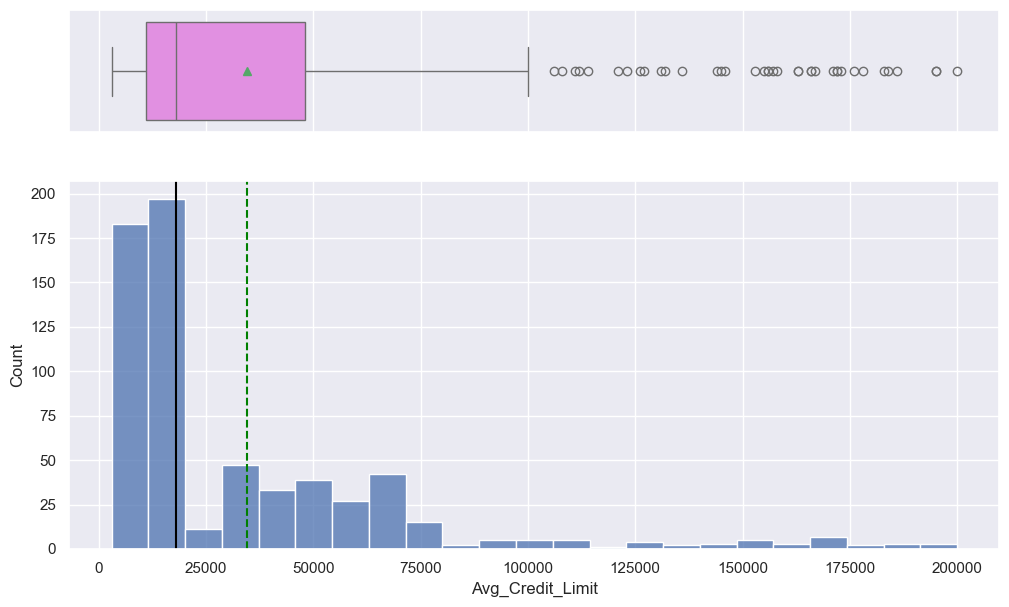

In [13]:
histogram_boxplot(df, 'Avg_Credit_Limit')

- The distribution is quite right-skewed
- There are some outliers after 100,000

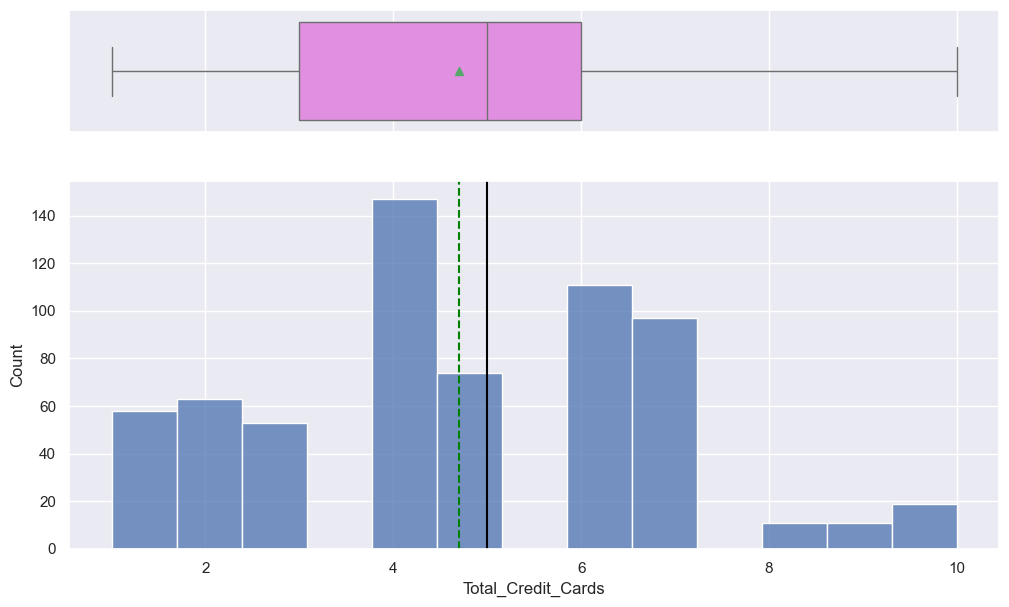

In [14]:
histogram_boxplot(df, 'Total_Credit_Cards')

- The ditribution looks like normal
- There is no outlier for this column
- There are fewer customers which has 8 or more credit cards

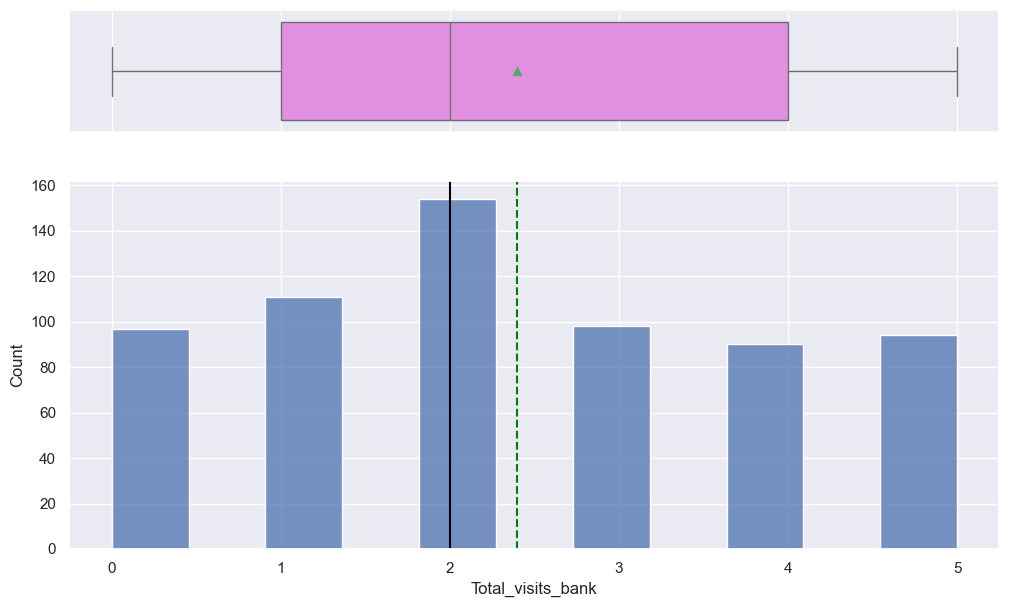

In [15]:
histogram_boxplot(df, 'Total_visits_bank')

- The largest number of customers visited the bank 2 times. 
- There is no outliers in this column

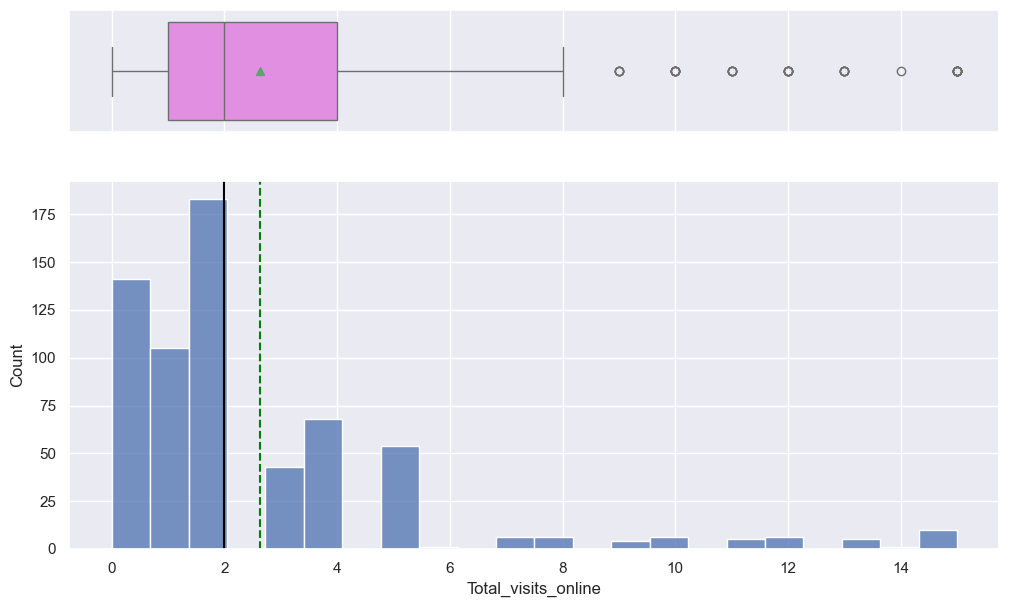

In [16]:
histogram_boxplot(df, 'Total_visits_online')

- The distribution of the total online vists is right-skew
- Most of the customers have 2 or less online visit.
- There are some few customers which had more than 10 times online visit.

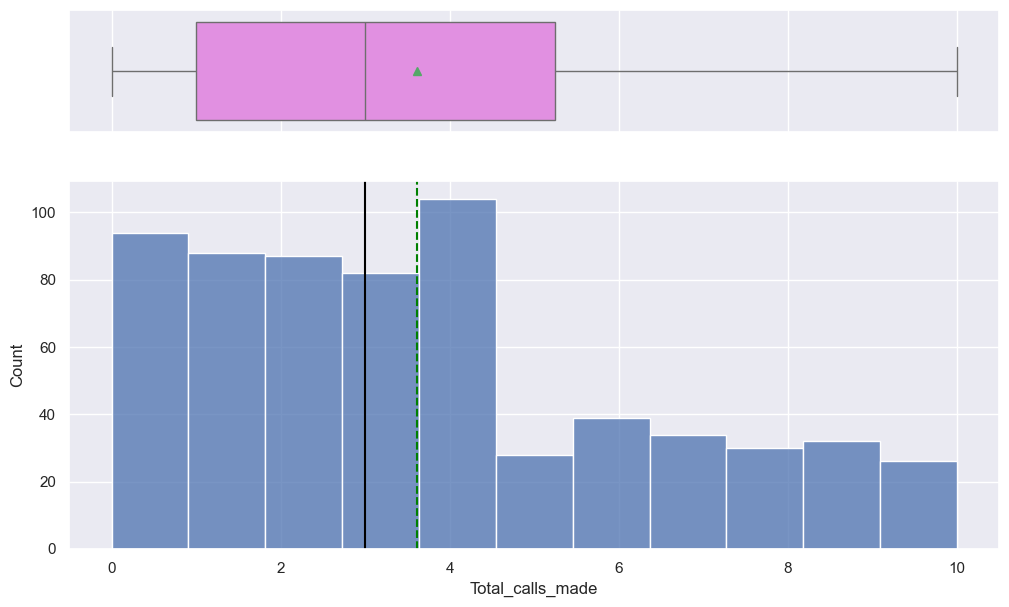

In [17]:
histogram_boxplot(df, 'Total_calls_made')

- Most of the customers have 4 or less calls. 
- There is no outlier in this part.

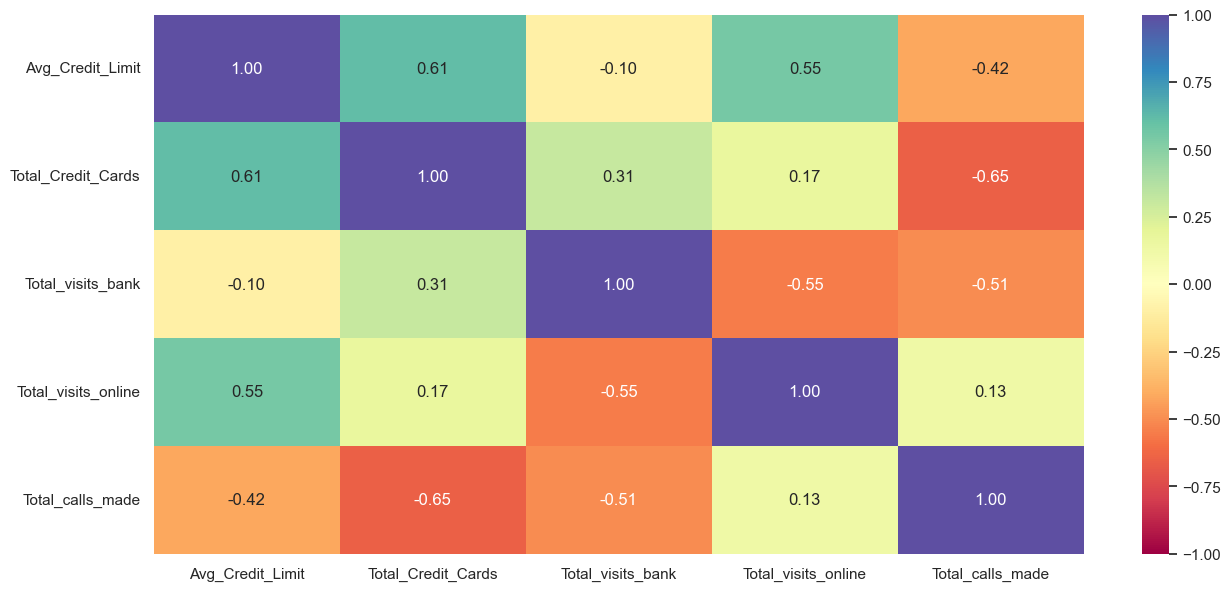

In [18]:
# Correlation check
cols_list = df.select_dtypes(include = np.number).columns.tolist()

plt.figure(figsize = (15, 7))

sns.heatmap(
    df[cols_list].corr(numeric_only = True), annot = True, vmin = -1, vmax = 1, fmt = ".2f", cmap = "Spectral"
)

plt.show()

- There is a correlation between number of credit cards and and avarage of credit limit which make sense the customers who have more credit cards will have higher average of credit limit. 
- There is also correlation between avarage credit limit and total visit online. 
- There is a negative correlation between total credit cards and total calls made. 
- There is negative correlation between online visits and visiting bank which shows customers who visit the bank personally and online are different.
- There is also negative correlation between visiting bank and making calls. Here also shows the difference between customer who prefere to do their job personally and the one who prefer to make from distance. 

#### **Scaling the data**

In [19]:
# scaling the data (all the columns are numeric)
scaler = StandardScaler()
scaled_df = pd.DataFrame(scaler.fit_transform(df), columns = df.columns)
scaled_df.head(2)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1.750192,-1.239437,-0.858684,-0.549573,-1.253982
1,0.413280,-0.779381,-1.473803,2.495669,1.873420


#### **Applying PCA on scaled data**

In [20]:
# Importing PCA
from sklearn.decomposition import PCA

# Defining the number of principal components to generate
n = scaled_df.shape[1]                                                 # Storing the number of variables in the data

pca = PCA(n_components = n, random_state = 1)                       # Storing PCA function with n components

data_pca = pd.DataFrame(pca.fit_transform(scaled_df ))       # Applying PCA on scaled data

# The percentage of variance explained by each principal component is stored
exp_var = (pca.explained_variance_ratio_)    

## **K-Means**

Let us now fit the K-means algorithm on our pca components and find out the optimum number of clusters to use.

We will do this in 3 steps:
1. Initialize a dictionary to store the Sum of Squared Error (SSE) for each K
2. Run for a range of Ks and store SSE for each run
3. Plot the SSE vs K and plot the elbow curve

In [21]:
k_means_df = data_pca.copy()  

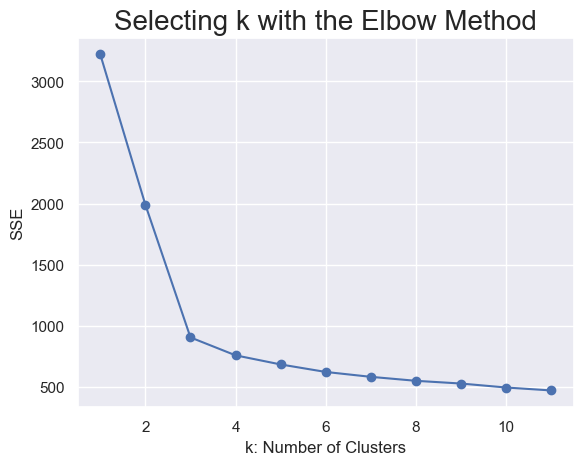

In [22]:
# Choose best number for clusters using the elbow method finding sse 
clusters = range(1, 12)
sse= {}

for k in clusters:
    model = KMeans(n_clusters = k, random_state = 1, max_iter = 1000)
    model.fit(data_pca)

    sse[k] = model.inertia_


plt.plot(list(sse.keys()), list(sse.values()), marker = "o")
plt.xlabel("k: Number of Clusters")
plt.ylabel("SSE")
plt.title("Selecting k with the Elbow Method", fontsize = 20)
plt.show()

- From k=3, the graph starts to move almost parallel to the x-axis. This k is the optimal number for clusters.
- Now we will fit K-means algorithm on pca components with the number of clusters = 3


In [23]:
kmeans = KMeans(n_clusters =3, random_state = 1, n_init = "auto")
kmeans.fit(k_means_df)

KMeans(n_clusters=3, n_init='auto', random_state=1)

#### **Create the cluster profiles using the summary statistics and box plots for each label**

In [24]:
# Creating a copy of the original data
df1 = df.copy()

# Adding K-Means cluster labels to the K-Means and original dataframes
k_means_df["KM_segments"] = kmeans.labels_
df1["KM_segments"] = kmeans.labels_

In [25]:
km_cluster_profile = df1.groupby("KM_segments").mean(numeric_only = True)

In [26]:
# Creating the "count_in_each_segment" feature in K-Means cluster profile

km_cluster_profile["count_in_each_segment"] = (
    df1.groupby("KM_segments")["Avg_Credit_Limit"].count().values
)

In [45]:
km_cluster_profile.style.highlight_max(color = "lightgreen", axis = 0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_each_segment
KM_segments,,,,,,
0,12239.819005,2.411765,0.945701,3.561086,6.891403,221
1,33893.048128,5.508021,3.489305,0.975936,1.997326,374
2,140102.040816,8.775510,0.591837,10.979592,1.102041,49


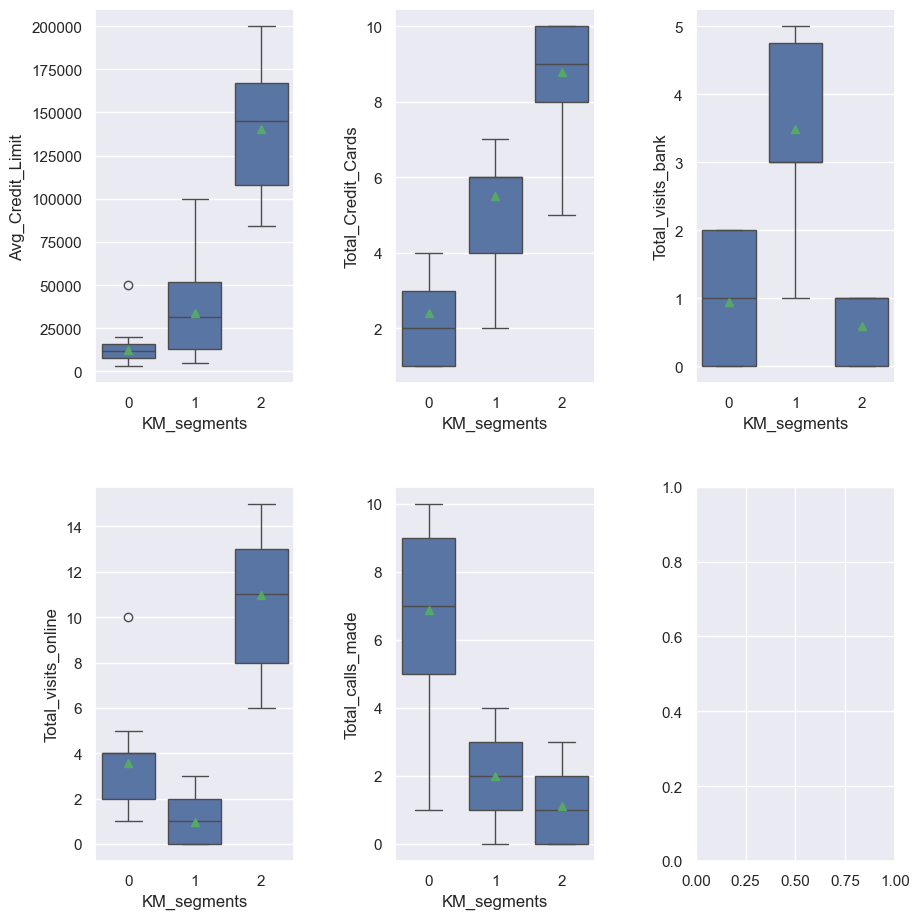

In [28]:
# visulize different features k-means labels
fig, axes = plt.subplots(2, 3, figsize = (10,10))
counter = 0

for ii in range(2):
    for jj in range(3):
        if counter < 5:
            sns.boxplot(
                ax = axes[ii][jj],
                data = df1,
                y = df1.columns[ counter],
                x = "KM_segments", showmeans = True
            )
            counter = counter + 1

fig.tight_layout(pad = 3.0)

**Cluster Profiles:_______________**
- There are 221 customers in group 0, 374 customers in group 1, and 49 customers in group 2.

- Group0:
    - Clients with most phone calls
    - Most of the clients have lower credit cards and lower credit limit compare to the other two groups.
    - Most of them have low personal visits. 
- Group1:
    - Most of the clients in this group have high personal visits. 
    - Most of them have medium credit limit and credit cards.
    - Most of the clients have lowest online visit also low calls.
- Group2:
    - Most of the clients in this group have the higher credit limits and credit cards.
    - Most of them have higher online visits.
    - Most of the clients in this group have low calls and personal visits. 


## **Gaussian Mixture Model**

Let's now create clusters using the Gaussian Mixture Model.

- Apply the Gaussian Mixture Model algorithm on the pca components

In [29]:
gmm_df = data_pca.copy()

#### **Create the cluster profiles using the summary statistics and box plots for each label**


In [30]:
gmm = GaussianMixture(n_components = 3, random_state = 1)  # Initializing the Gaussian Mixture algorithm with n_components = 3

gmm.fit(gmm_df)   

GaussianMixture(n_components=3, random_state=1)

In [31]:
# Creating a copy of the original data
df3 = df.copy()

# Adding GMM cluster labels to the original and scaled dataframes
gmm_df["GMM_segments"] = gmm.predict(gmm_df)
df3["GMM_segments"] = gmm.predict(data_pca)

In [32]:
gmm_cluster_profile = df3.groupby("GMM_segments").mean(numeric_only = True)

In [33]:
gmm_cluster_profile["count_in_each_segment"] = (
    df3.groupby("GMM_segments")["Avg_Credit_Limit"].count().values
)


In [46]:
gmm_cluster_profile.style.highlight_max(color = "lightgreen", axis = 0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_each_segment
GMM_segments,,,,,,
0,12239.819005,2.411765,0.945701,3.561086,6.891403,221
1,33893.048128,5.508021,3.489305,0.975936,1.997326,374
2,140102.040816,8.775510,0.591837,10.979592,1.102041,49


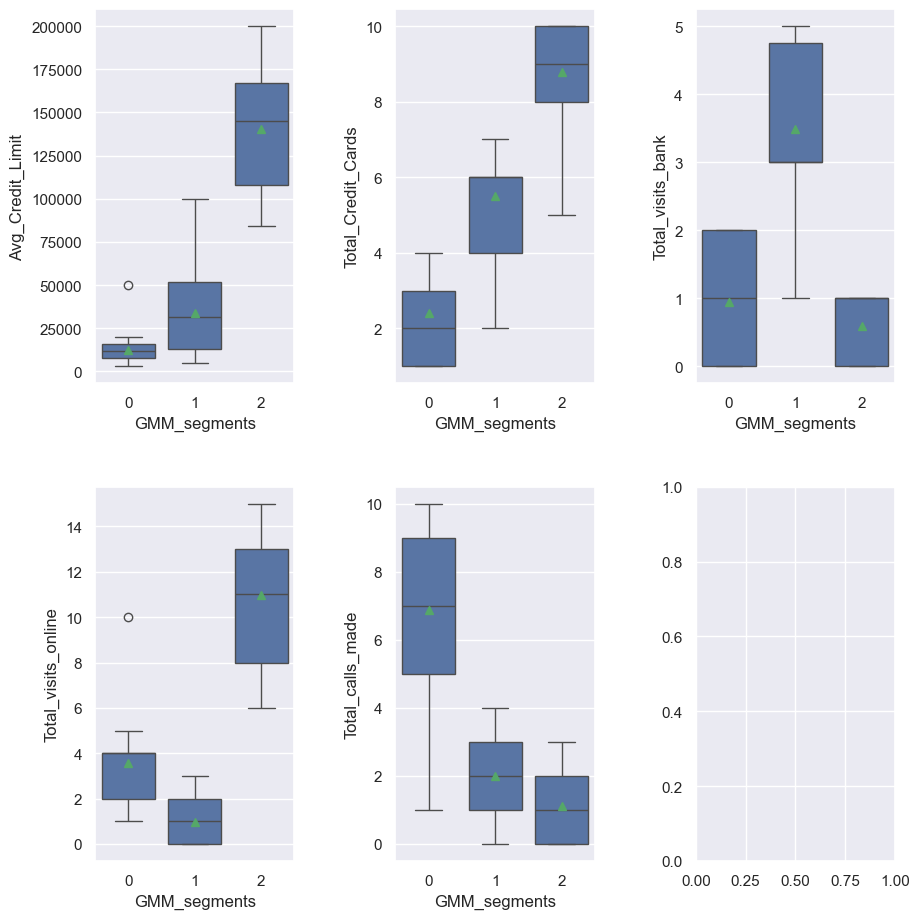

In [35]:
fig, axes = plt.subplots(2, 3, figsize = (10,10))
counter = 0

for ii in range(2):
    for jj in range(3):
        if counter < 5:
            sns.boxplot(
                ax = axes[ii][jj],
                data = df3,
                y = df3.columns[counter],
                x = "GMM_segments",showmeans = True
            )
            counter = counter + 1

fig.tight_layout(pad = 3.0)

#### **Compare the clusters from both algorithms - K-means and Gaussian Mixture Model**

In [36]:
comparison_gmm_kmeans = pd.concat(
    [gmm_cluster_profile, km_cluster_profile], axis=0, keys=["GMM", "K-Means"]
)

In [37]:
comparison_gmm_kmeans

Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  \
        GMM_segments                                                            
GMM     0                 12239.819005            2.411765           0.945701   
        1                 33893.048128            5.508021           3.489305   
        2                140102.040816            8.775510           0.591837   
K-Means 0                 12239.819005            2.411765           0.945701   
        1                 33893.048128            5.508021           3.489305   
        2                140102.040816            8.775510           0.591837   

                      Total_visits_online  Total_calls_made  \
        GMM_segments                                          
GMM     0                        3.561086          6.891403   
        1                        0.975936          1.997326   
        2                       10.979592          1.102041   
K-Means 0                        3.561086          6.891403   
        1                        0.975936          1.997326   
        2                       10.979592          1.102041   

                      count_in_each_segment  
        GMM_segments                         
GMM     0                               221  
        1                               374  
        2                                49  
K-Means 0                               221  
        1                               374  
        2                                49

**Comparing Clusters:____________**
- The clustering in K-mean and GGM is exactly the same. 
- The groups have the same number of clients with the same cluster profile. 

## **K-Medoids**



- Apply the K-Medoids clustering algorithm on the pca components

In [38]:
k_med_df = data_pca.copy()

In [39]:
kmed = KMedoids(n_clusters = 3, random_state = 1) # Create K-Medoids with nclusters = 3
kmed.fit(k_med_df)

KMedoids(n_clusters=3, random_state=1)

In [40]:
# Creating a copy of the original data
df2 = df.copy()

# Add K-Medoids cluster labels to K-Medoids data
k_med_df["KMed_segments"] = kmed.labels_
# Add K-Medoids cluster labels to the whole data
df2["KMed_segments"] =  kmed.labels_

#### **Create cluster profiles using the summary statistics and box plots for each label**

In [41]:
kmed_cluster_profile = df2.groupby("KMed_segments").mean(numeric_only = True)

In [47]:
kmed_cluster_profile["count_in_each_segment"] = (
    df2.groupby("KMed_segments")["Avg_Credit_Limit"].count().values
)

kmed_cluster_profile.style.highlight_max(color = "lightgreen", axis = 0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_each_segment
KMed_segments,,,,,,
0,12216.216216,2.423423,0.950450,3.554054,6.878378,222
1,85052.631579,7.030075,1.691729,4.639098,1.969925,133
2,28449.826990,5.363322,3.830450,0.982699,1.851211,289


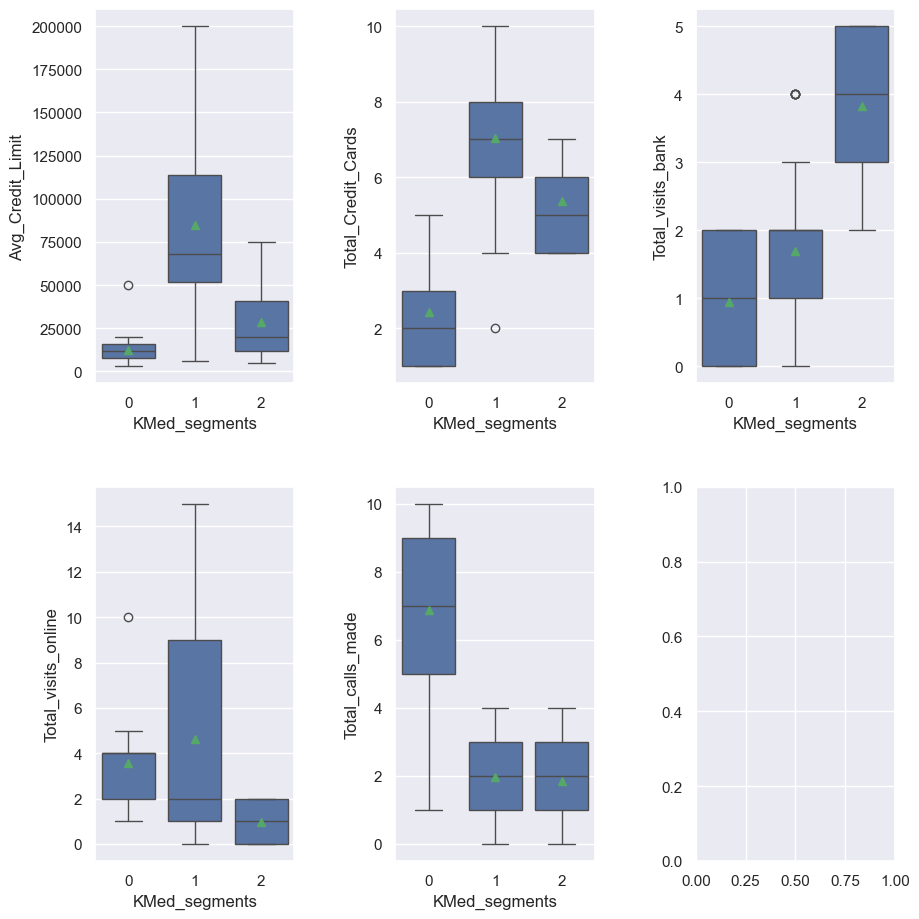

In [43]:
fig, axes = plt.subplots(2, 3, figsize = (10,10))
counter = 0

for ii in range(2): # 2 rows of plots
    for jj in range(3): # 3 columns of plots
        if counter < 5:
            sns.boxplot(
                ax = axes[ii][jj],
                data = df2,
                y = df2.columns[counter],
                x = "KMed_segments", showmeans = True
            )
            counter = counter + 1

fig.tight_layout(pad = 3.0)

**Cluster Profiles:____________**
- There are 222 customers in group0, 133 customers in group1, 289 customers in group2.
- The number of customers in different groups looks more fair.
- Group0:
    - Clients with most phone calls
    - Most of the clients have lower credit cards and lower credit limit compare to the other two groups.
    - Most of them have low personal visits. 

- Group1:
    - Most of the clients in this group have the higher credit limits and credit cards.
    - Most of them have higher online visits.
    - Most of the clients in this group have low calls and personal visits. 

- Group2:
    - Most of the clients in this group have high personal visits. 
    - Most of them have medium credit limit and credit cards.
    - Most of the clients have lowest online visit also low calls. 

#### **Compare the clusters from K-Means and K-Medoids** 

In [44]:
comparisin_kmed_kmeans = pd.concat(
    [kmed_cluster_profile, km_cluster_profile], axis=0, keys=["K-Medoids", "K-Means"]
)
comparisin_kmed_kmeans

Avg_Credit_Limit  Total_Credit_Cards  \
          KMed_segments                                         
K-Medoids 0                  12216.216216            2.423423   
          1                  85052.631579            7.030075   
          2                  28449.826990            5.363322   
K-Means   0                  12239.819005            2.411765   
          1                  33893.048128            5.508021   
          2                 140102.040816            8.775510   

                         Total_visits_bank  Total_visits_online  \
          KMed_segments                                           
K-Medoids 0                       0.950450             3.554054   
          1                       1.691729             4.639098   
          2                       3.830450             0.982699   
K-Means   0                       0.945701             3.561086   
          1                       3.489305             0.975936   
          2                       0.591837            10.979592   

                         Total_calls_made  count_in_each_segment  
          KMed_segments                                           
K-Medoids 0                      6.878378                    222  
          1                      1.969925                    133  
          2                      1.851211                    289  
K-Means   0                      6.891403                    221  
          1                      1.997326                    374  
          2                      1.102041                     49

**Comparing Clusters:___________________**
- There is a difference in the distribution of each cluster: The cluster groups in K-Medoids are more evenly distributed.
- The cluster profiles are the same for both algorithms. Even though the cluster number is changing but cluster profiles remain the same. 

## **Conclusions and Business Recommendations**

## **Conclusion**

- The clients who have the higher number of credit cards and higher average of credit limit tent to visit the bank more online. (cluster 1) These customers are financially significant and digitally engaged.
- The client who have the lowest number of credit cards and lower average of credit limit tent to call the bank more. (cluster 2) These customers rely heavily on phone support, suggesting discomfort or lack of trust in digital channels.

- The clients who have the highest number of personal visits normally have lowest number of visiting the bank online. The clients in this group have a medium number of credit cards (between 4 to 7) and a medium amount of credit limit. (cluster3) Indicates a middle tier of customers with potential for upselling but require personal engagement.

## **Recommendation**

- Upgrade service delivery based on customer categorie:
    - Cluster 1: Enhance online support (e.g., chatbot, live chat, self-service knowledge base).

    - Cluster 2: Improve call center response times and offer callbacks. Consider adding voice biometrics for faster authentication.

    - Cluster 3: Train in-branch staff to resolve issues more efficiently; perhaps introduce a mobile concierge system to manage appointments and service follow-ups.

- Personalize Campaigns Based on Channel Preferences

    - Cluster 1: Promote new premium card offerings or limit increases through email, app, and web-based campaigns. These clients are likely to respond positively to digital offers.

    - Cluster 2: Use voice/SMS-based promotions. Consider educational content or one-on-one advisor calls to build digital trust and promote basic credit card usage.

    - Cluster 3: Branch-based events, seminars, or personal banker interactions to upsell additional products like co-branded cards or add-on benefits.